<a href="https://colab.research.google.com/github/LuisMesa10/DeepLearning/blob/main/RETO_1_3SCENES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# FASE - 1 - MEJORA DEL NOTEBOOK BASE
# OBJETIVO:
# Implementar una versión corregida y mejor documentada del
# modelo base de clasificación de 3 escenas:
#   - coast
#   - forest
#   - highway
#
# En esta primera fase NO se modifica la arquitectura CNN.
# Se mejora el experimento en términos de:
#   1) reproducibilidad
#   2) separación adecuada train / validation / test
#   3) evaluación matemática y gráfica
#
# Esto servirá como línea base sólida para comparar luego
# con una CNN mejorada y con una arquitectura no secuencial.
# =========================================================

# =========================================================
# 1. IMPORTACIONES
# =========================================================

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google.colab import drive

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Activation, Flatten, Dense
from tensorflow.keras.optimizers import Adam


In [2]:
# =========================================================
# 2. MONTAJE DE GOOGLE DRIVE
# =========================================================

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

# =========================================================
# 3. CONFIGURACIÓN GENERAL Y SEMILLAS
# =========================================================
# Fijamos semillas para hacer el experimento reproducible.
# Esto ayuda a que la partición de datos y varios procesos
# aleatorios sean consistentes entre ejecuciones.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Ruta base del dataset
base_path = '/content/drive/MyDrive/3scenes'

# Nombres de las carpetas (cada carpeta representa una clase)
subfolders = ['coast', 'forest', 'highway']

# Tamaño al que se redimensionarán todas las imágenes
IMG_SIZE = (128, 128)

In [4]:
# =========================================================
# 4. CARGA Y PREPROCESAMIENTO DE IMÁGENES
# =========================================================
# En este bloque:
#   - recorremos cada carpeta
#   - leemos imágenes JPG
#   - las redimensionamos a 128x128
#   - normalizamos los pixeles a [0, 1]
#   - guardamos la imagen y su etiqueta

data = []
labels = []

for subfolder in subfolders:
    current_folder_path = os.path.join(base_path, subfolder)

    # Verificamos que la carpeta exista
    if not os.path.exists(current_folder_path):
        raise FileNotFoundError(f"No se encontró la carpeta: {current_folder_path}")

    files = [f for f in os.listdir(current_folder_path) if f.lower().endswith('.jpg')]

    for file in files:
        img_path = os.path.join(current_folder_path, file)

        # Lectura de la imagen
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        # Si la imagen no pudo cargarse, se omite
        if img is None:
            print(f"Advertencia: no se pudo leer {img_path}")
            continue

        # Redimensionar primero
        img = cv2.resize(img, IMG_SIZE)

        # Convertir a float32 y normalizar a [0, 1]
        img = img.astype('float32') / 255.0

        data.append(img)
        labels.append(subfolder)

# Convertimos a arreglos de NumPy
data = np.array(data, dtype='float32')
labels = np.array(labels)

print("Cantidad total de imágenes:", len(data))
print("Forma del arreglo de imágenes:", data.shape)
print("Cantidad total de etiquetas:", len(labels))

# Mostrar cuántas imágenes hay por clase
print("\nDistribución por clase:")
for clase in subfolders:
    print(f"{clase}: {np.sum(labels == clase)}")

Cantidad total de imágenes: 958
Forma del arreglo de imágenes: (958, 128, 128, 3)
Cantidad total de etiquetas: 958

Distribución por clase:
coast: 360
forest: 328
highway: 270


In [5]:
# =========================================================
# 5. CODIFICACIÓN DE ETIQUETAS
# =========================================================
# Convertimos las etiquetas de texto a formato one-hot.
# Ejemplo:
#   coast   -> [1,0,0]
#   forest  -> [0,1,0]
#   highway -> [0,0,1]

lb = LabelBinarizer()
labels_encoded = lb.fit_transform(labels)

print("\nClases detectadas por LabelBinarizer:")
print(lb.classes_)


Clases detectadas por LabelBinarizer:
['coast' 'forest' 'highway']


In [6]:
# =========================================================
# 6. DIVISIÓN TRAIN / VALIDATION / TEST
# =========================================================
# Queremos una separación más correcta que en el notebook original.
#
# Estrategia:
#   Paso 1: separar 20% para test
#   Paso 2: del 80% restante, separar 25% para validation
#
# Resultado final:
#   Train      = 60%
#   Validation = 20%
#   Test       = 20%
#
# Además usamos stratify para conservar proporciones por clase.

# Primer split: train_val y test
trainValX, testX, trainValY, testY, trainValLabels, testLabels = train_test_split(
    data,
    labels_encoded,
    labels,  # etiquetas originales para estratificar e interpretar
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

# Segundo split: train y validation
trainX, valX, trainY, valY, trainLabels, valLabels = train_test_split(
    trainValX,
    trainValY,
    trainValLabels,
    test_size=0.25,   # 25% de 80% = 20% del total
    random_state=SEED,
    stratify=trainValLabels
)

print("\nTamaños finales:")
print("Train:", trainX.shape, trainY.shape)
print("Validation:", valX.shape, valY.shape)
print("Test:", testX.shape, testY.shape)


Tamaños finales:
Train: (574, 128, 128, 3) (574, 3)
Validation: (192, 128, 128, 3) (192, 3)
Test: (192, 128, 128, 3) (192, 3)


In [7]:
# =========================================================
# 7. CONSTRUCCIÓN DEL MODELO BASE (SIN MODIFICAR ARQUITECTURA)
# =========================================================
# Mantenemos la misma arquitectura del profesor:
#   Conv(8)  -> ReLU -> MaxPool
#   Conv(16) -> ReLU -> MaxPool
#   Conv(32) -> ReLU -> MaxPool
#   Flatten  -> Dense(3) -> Softmax
#
# Única mejora formal aquí:
# usamos Input() de forma explícita para evitar el warning.

model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(8, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(16, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(32, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Flatten(),
    Dense(3),
    Activation("softmax")
])

print("\nResumen del modelo:")
model.summary()



Resumen del modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │        24,579 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,611 (119.57 KB)

 Trainable params: 30,611 (119.57 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# =========================================================
# 8. COMPILACIÓN DEL MODELO
# =========================================================
# Usamos Adam con learning rate fijo 1e-3.
# NO usamos el parámetro decay porque en versiones recientes
# de Keras ya no se soporta y sería ignorado.

opt = Adam(learning_rate=1e-3)

model.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)

In [9]:
# =========================================================
# 9. ENTRENAMIENTO
# =========================================================
# Ahora sí usamos validation_data correctamente sobre valX, valY
# y reservamos testX/testY para la evaluación final.

EPOCHS = 15
BATCH_SIZE = 32

history = model.fit(
    trainX, trainY,
    validation_data=(valX, valY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 391ms/step - accuracy: 0.3798 - loss: 1.0601 - val_accuracy: 0.6250 - val_loss: 0.9320
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 435ms/step - accuracy: 0.7422 - loss: 0.7914 - val_accuracy: 0.7083 - val_loss: 0.5880
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.7666 - loss: 0.5424 - val_accuracy: 0.8958 - val_loss: 0.3830
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 302ms/step - accuracy: 0.8624 - loss: 0.4190 - val_accuracy: 0.8542 - val_loss: 0.3921
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 411ms/step - accuracy: 0.8780 - loss: 0.3637 - val_accuracy: 0.8854 - val_loss: 0.3016
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 301ms/step - accuracy: 0.8937 - loss: 0.3011 - val_accuracy: 0.9010 - val_loss: 0.2682
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 454ms/step - accuracy: 0.9111 - loss: 0.2789 - val_accuracy: 0.8958 - val_loss: 0.2849
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 295ms/step - accuracy: 0.9181 - loss: 0.2599 - val_accuracy: 0

In [10]:
# =========================================================
# 10. EVALUACIÓN FINAL EN TEST
# =========================================================
# Este bloque se ejecuta solo al final, usando el conjunto
# de prueba que no participó durante el entrenamiento.

pred_probs = model.predict(testX, batch_size=BATCH_SIZE)
pred_classes = pred_probs.argmax(axis=1)
true_classes = testY.argmax(axis=1)

test_acc = accuracy_score(true_classes, pred_classes)

print("\nAccuracy final en TEST:", round(test_acc, 4))

print("\nReporte de clasificación en TEST:")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=lb.classes_
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step

Accuracy final en TEST: 0.9271

Reporte de clasificación en TEST:
              precision    recall  f1-score   support

       coast       0.91      0.89      0.90        72
      forest       1.00      0.98      0.99        66
     highway       0.86      0.91      0.88        54

    accuracy                           0.93       192
   macro avg       0.92      0.93      0.93       192
weighted avg       0.93      0.93      0.93       192



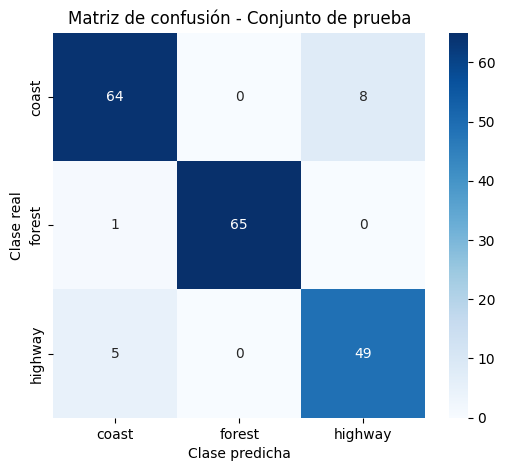

In [11]:
# =========================================================
# 11. MATRIZ DE CONFUSIÓN
# =========================================================
# La matriz de confusión permite ver en qué clases se equivoca
# más el modelo y entre cuáles ocurre la confusión.

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lb.classes_,
    yticklabels=lb.classes_
)
plt.title('Matriz de confusión - Conjunto de prueba')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.show()


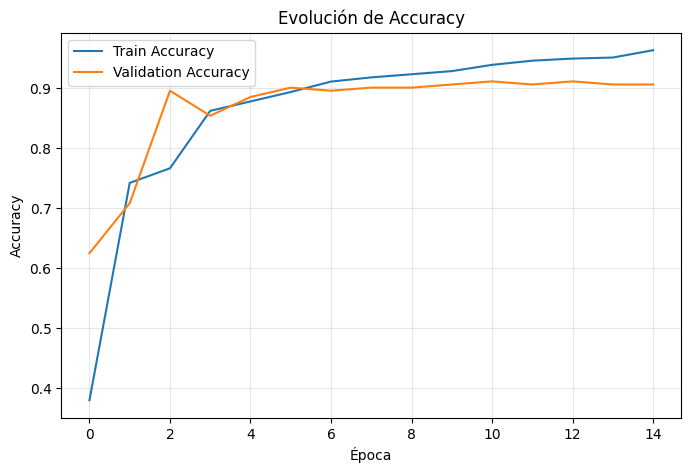

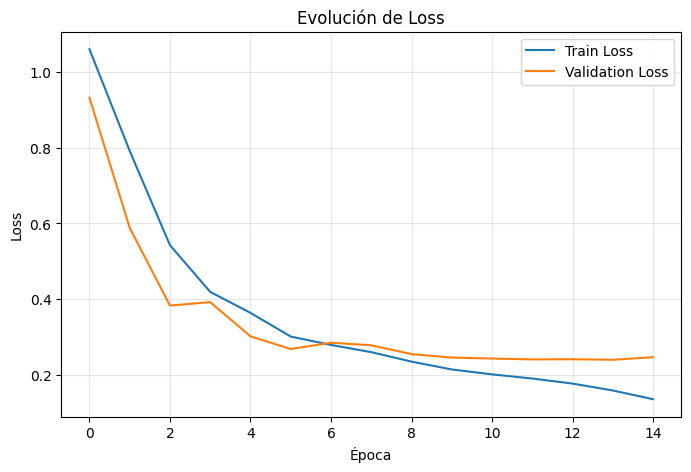

In [12]:
# =========================================================
# 12. CURVAS DE ENTRENAMIENTO
# =========================================================
# Graficamos cómo evolucionan accuracy y loss tanto en train
# como en validation.

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Evolución de Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolución de Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

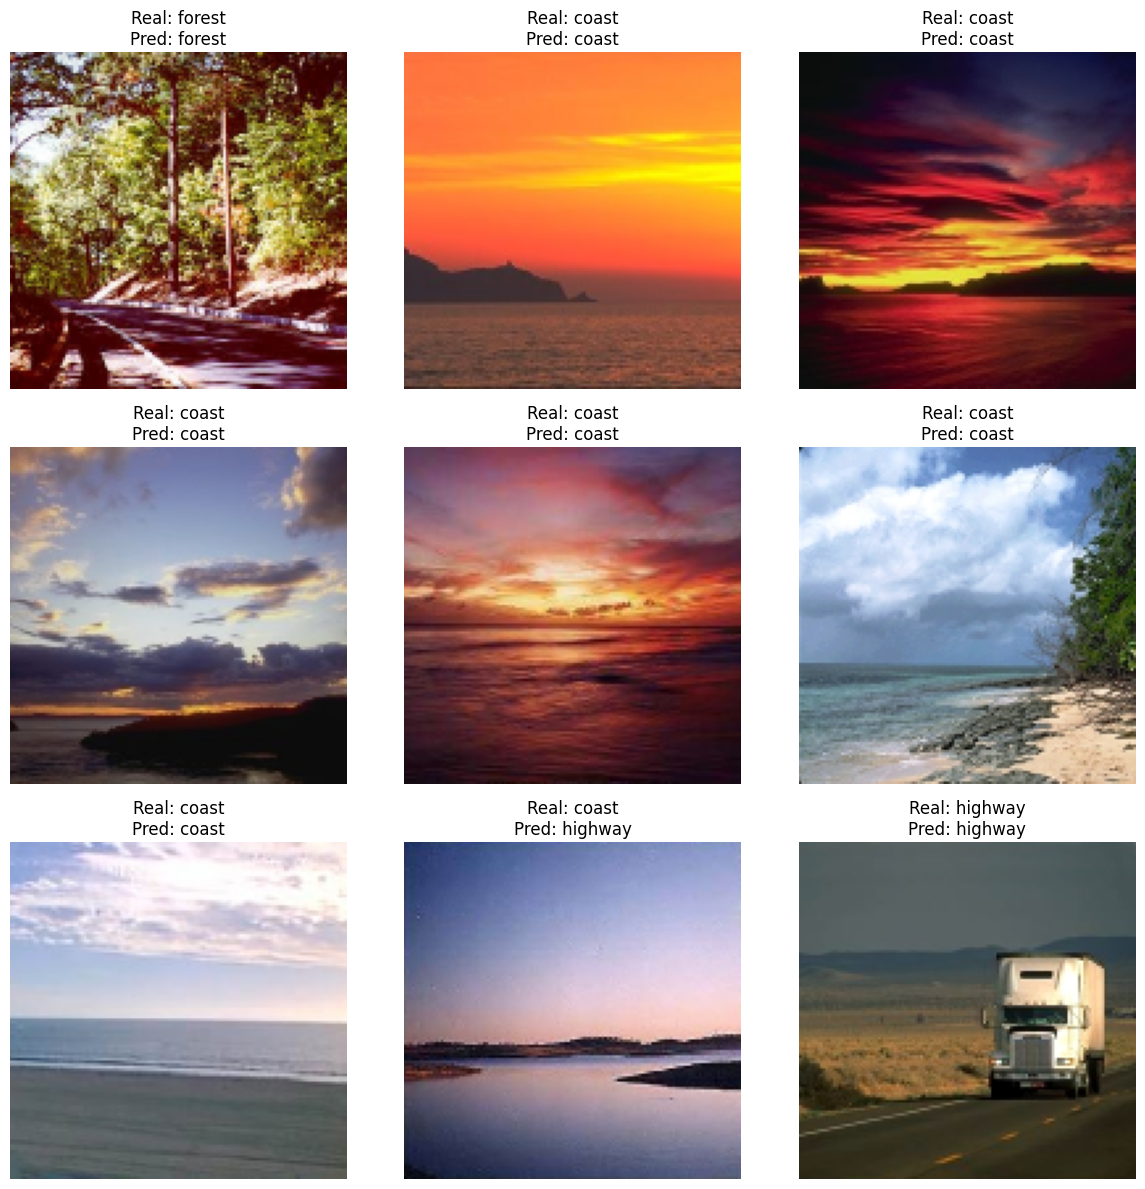

In [13]:
# =========================================================
# 13. VISUALIZACIÓN DE ALGUNAS PREDICCIONES
# =========================================================
# Mostramos algunas imágenes del conjunto de prueba con:
#   - clase real
#   - clase predicha
# Esto ayuda a interpretar cualitativamente los resultados.

num_samples = 9
indices = np.random.choice(len(testX), size=min(num_samples, len(testX)), replace=False)

plt.figure(figsize=(12, 12))

for i, idx in enumerate(indices, 1):
    img = testX[idx]
    true_label = lb.classes_[true_classes[idx]]
    pred_label = lb.classes_[pred_classes[idx]]

    # OpenCV carga en BGR, pero matplotlib muestra en RGB
    # Para visualización, convertimos BGR -> RGB
    img_rgb = cv2.cvtColor((img * 255).astype('uint8'), cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i)
    plt.imshow(img_rgb)
    plt.title(f"Real: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Análisis de mejoras respecto al notebook base

## Cambios implementados

En esta versión del modelo se realizaron mejoras principalmente a nivel metodológico y experimental, manteniendo inicialmente la misma arquitectura convolucional propuesta en el notebook base. Los cambios más relevantes fueron:

- **Control de reproducibilidad** mediante la fijación de semillas (`random`, `numpy`, `tensorflow`), lo cual permite obtener resultados consistentes entre ejecuciones.
- **Separación adecuada del dataset** en tres subconjuntos: entrenamiento (60%), validación (20%) y prueba (20%), evitando el uso del conjunto de prueba durante el entrenamiento.
- **División estratificada (`stratify`)**, asegurando que la proporción de clases (`coast`, `forest`, `highway`) se mantenga equilibrada en todos los subconjuntos.
- **Corrección del flujo de validación**, utilizando el conjunto de validación para monitorear el desempeño durante el entrenamiento, en lugar del conjunto de prueba.
- **Mejoras en la evaluación del modelo**, incluyendo:
  - matriz de confusión,
  - curvas de entrenamiento (accuracy y loss),
  - visualización de predicciones,
  - métricas detalladas (precision, recall, F1-score).
- **Corrección en la compilación del modelo**, eliminando el parámetro `decay` del optimizador Adam, ya que no es soportado en versiones recientes de Keras.

---

## Comparación con el modelo base

| Aspecto                     | Notebook base                     | Versión actual                          |
|----------------------------|----------------------------------|-----------------------------------------|
| División de datos          | Train/Test (75/25)               | Train/Validation/Test (60/20/20)        |
| Uso del test               | También como validación          | Exclusivo para evaluación final         |
| Reproducibilidad           | No definida                      | Semillas controladas                    |
| Estratificación            | No                               | Sí (`stratify`)                         |
| Evaluación                 | Accuracy + classification report | Métricas completas + gráficas           |
| Arquitectura               | CNN básica                       | Igual (sin cambios en esta fase)        |
| Optimización               | Adam con decay ignorado          | Adam correctamente configurado          |

---

## Análisis de resultados

El modelo alcanzó una **accuracy cercana al 92–93% en el conjunto de prueba**, lo cual representa un desempeño sólido para una arquitectura simple.

Se observan los siguientes patrones:

- **La clase `forest` presenta el mejor desempeño**, con métricas cercanas a la perfección. Esto sugiere que sus características visuales son más distintivas.
- **La clase `highway` continúa siendo la más difícil**, con menor F1-score. Esto puede deberse a mayor variabilidad visual o similitud con otras clases.
- **La clase `coast` muestra un comportamiento intermedio**, con buen balance entre precision y recall.

En las curvas de entrenamiento:

- La **accuracy de entrenamiento alcanza valores superiores al 95%**, mientras que la de validación se estabiliza alrededor del 90–91%.
- Esto indica un **ligero sobreajuste**, aunque no crítico.

La matriz de confusión confirma que los errores se concentran principalmente entre `highway` y otras clases, lo cual es coherente con el análisis anterior.

---

## Mejoras logradas

Las mejoras introducidas no buscan aumentar artificialmente el desempeño, sino **hacer el experimento más riguroso y confiable**. En este sentido, los avances más importantes son:

- Evaluación más realista del modelo, al separar correctamente validación y prueba.
- Resultados reproducibles y comparables entre experimentos.
- Mayor capacidad de diagnóstico del modelo mediante métricas y visualizaciones.
- Base sólida para comparar futuras mejoras arquitectónicas.

---

## Conclusiones

1. **Una correcta metodología de entrenamiento y validación es tan importante como la arquitectura del modelo.** La separación adecuada de datos y el uso de validación independiente permiten obtener resultados más confiables.

2. **El modelo base ya presenta un buen desempeño, pero evidencia limitaciones en clases más complejas como `highway`.** Esto sugiere que futuras mejoras deben enfocarse en aumentar la capacidad de representación del modelo.

3. **El análisis detallado mediante métricas y gráficas permite identificar patrones de error y sobreajuste, lo cual es fundamental para justificar mejoras posteriores en la arquitectura.**

In [28]:
# =========================================================
# FASE 2
# CNN MODIFICADA CAMBIANDO FILTROS Y AÑADIENDO UNA 4TA CAPA
# =========================================================
#
# OBJETIVO:
# Adaptar la arquitectura base vista en clase para tratar de
# mejorar la clasificación de las 3 escenas:
#   - coast
#   - forest
#   - highway
#
# CAMBIOS REALIZADOS RESPECTO AL MODELO BASE:
#   1. Se aumenta el número de filtros por capa:
#      8 -> 16 -> 32  pasa a  16 -> 32 -> 64 -> 64
#   2. Se agrega una cuarta capa convolucional
#
# =========================================================


# =========================================================
# 1. IMPORTACIONES NECESARIAS
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Activation, Flatten, Dense
from tensorflow.keras.optimizers import Adam



In [29]:
# =========================================================
# 2. CONSTRUCCIÓN DEL MODELO MODIFICADO
# =========================================================
# Arquitectura base original:
#   Conv(8)  -> ReLU -> MaxPool
#   Conv(16) -> ReLU -> MaxPool
#   Conv(32) -> ReLU -> MaxPool
#   Flatten  -> Dense(3) -> Softmax
#
# Nueva arquitectura:
#   Conv(16) -> ReLU -> MaxPool
#   Conv(32) -> ReLU -> MaxPool
#   Conv(64) -> ReLU -> MaxPool
#   Conv(64) -> ReLU -> MaxPool
#   Flatten  -> Dense(3) -> Softmax

model = Sequential([
    Input(shape=(128, 128, 3)),

    # -------------------------------------------------
    # BLOQUE 1
    # Extrae características visuales básicas
    # como bordes, contornos y texturas simples.
    # -------------------------------------------------
    Conv2D(16, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # -------------------------------------------------
    # BLOQUE 2
    # Aprende patrones un poco más complejos a partir
    # de las características detectadas en el bloque 1.
    # -------------------------------------------------
    Conv2D(32, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # -------------------------------------------------
    # BLOQUE 3
    # Aumentamos a 64 filtros para permitir que el
    # modelo capture una mayor variedad de patrones.
    # -------------------------------------------------
    Conv2D(64, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # -------------------------------------------------
    # BLOQUE 4 (NUEVO)
    # Esta capa adicional busca aprender patrones más
    # abstractos y de mayor nivel.
    # -------------------------------------------------
    Conv2D(64, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    # -------------------------------------------------
    # CLASIFICADOR FINAL
    # Flatten convierte los mapas de características
    # en un vector 1D para alimentar la capa densa.
    # Dense(3) produce una salida por cada clase.
    # Softmax convierte esas salidas en probabilidades.
    # -------------------------------------------------
    Flatten(),
    Dense(3),
    Activation("softmax")
])

print("====================================================")
print("RESUMEN DEL MODELO MODIFICADO")
print("====================================================")
model.summary()



RESUMEN DEL MODELO MODIFICADO


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │        12,291 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,803 (284.39 KB)

 Trainable params: 72,803 (284.39 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# =========================================================
# 3. COMPILACIÓN DEL MODELO
# =========================================================
# Se mantiene la misma función de costo:
# categorical_crossentropy
# porque es la adecuada para clasificación multiclase.
#
# Se usa Adam con learning rate 1e-3, como en el enfoque base.

opt = Adam(learning_rate=1e-3)

model.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)


In [31]:
# =========================================================
# 4. ENTRENAMIENTO DEL MODELO
# =========================================================
# Se entrena con el conjunto train y se monitorea usando
# el conjunto de validación.
#
# Aumentamos el número de épocas respecto al notebook base
# para darle oportunidad al modelo de aprovechar su mayor
# capacidad.

EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    trainX, trainY,
    validation_data=(valX, valY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 734ms/step - accuracy: 0.4251 - loss: 1.0897 - val_accuracy: 0.5885 - val_loss: 0.9287
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 565ms/step - accuracy: 0.6010 - loss: 0.7770 - val_accuracy: 0.7552 - val_loss: 0.5542
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 700ms/step - accuracy: 0.7230 - loss: 0.6501 - val_accuracy: 0.7812 - val_loss: 0.5762
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 680ms/step - accuracy: 0.8258 - loss: 0.5005 - val_accuracy: 0.8802 - val_loss: 0.3933
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 671ms/step - accuracy: 0.8432 - loss: 0.4203 - val_accuracy: 0.9115 - val_loss: 0.3363
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 565ms/step - accuracy: 0.8763 - loss: 0.3488 - val_accuracy: 0.9115 - val_loss: 0.3002
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 651ms/step - accuracy: 0.8955 - loss: 0.3009 - val_accuracy: 0.9323 - val_loss: 0.2514
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 702ms/step - accuracy: 0.9077 - loss: 0.2593 - val_accu

In [32]:
# =========================================================
# 5. EVALUACIÓN FINAL EN TEST
# =========================================================
# El conjunto test se usa únicamente al final para medir
# el desempeño real del modelo en datos no vistos.

pred_probs = model.predict(testX, batch_size=BATCH_SIZE)
pred_classes = pred_probs.argmax(axis=1)
true_classes = testY.argmax(axis=1)

test_acc = accuracy_score(true_classes, pred_classes)
precision_macro = precision_score(true_classes, pred_classes, average='macro')
recall_macro = recall_score(true_classes, pred_classes, average='macro')
f1_macro = f1_score(true_classes, pred_classes, average='macro')

print("\n====================================================")
print("RESULTADOS FINALES EN TEST")
print("====================================================")
print(f"Accuracy:        {test_acc:.4f}")
print(f"Precision macro: {precision_macro:.4f}")
print(f"Recall macro:    {recall_macro:.4f}")
print(f"F1-score macro:  {f1_macro:.4f}")

print("\nReporte de clasificación:")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=lb.classes_
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step

RESULTADOS FINALES EN TEST
Accuracy:        0.9271
Precision macro: 0.9250
Recall macro:    0.9266
F1-score macro:  0.9257

Reporte de clasificación:
              precision    recall  f1-score   support

       coast       0.92      0.90      0.91        72
      forest       0.98      0.97      0.98        66
     highway       0.88      0.91      0.89        54

    accuracy                           0.93       192
   macro avg       0.93      0.93      0.93       192
weighted avg       0.93      0.93      0.93       192



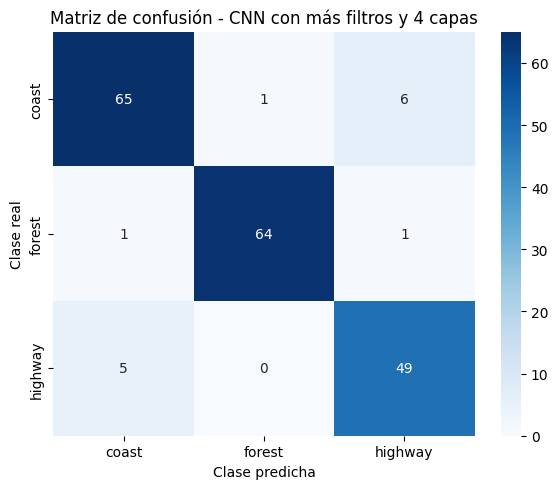

In [33]:
# =========================================================
# 6. MATRIZ DE CONFUSIÓN
# =========================================================
# Permite observar en qué clases acierta y en cuáles
# se presentan las principales confusiones.

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lb.classes_,
    yticklabels=lb.classes_
)
plt.title('Matriz de confusión - CNN con más filtros y 4 capas')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.tight_layout()
plt.show()


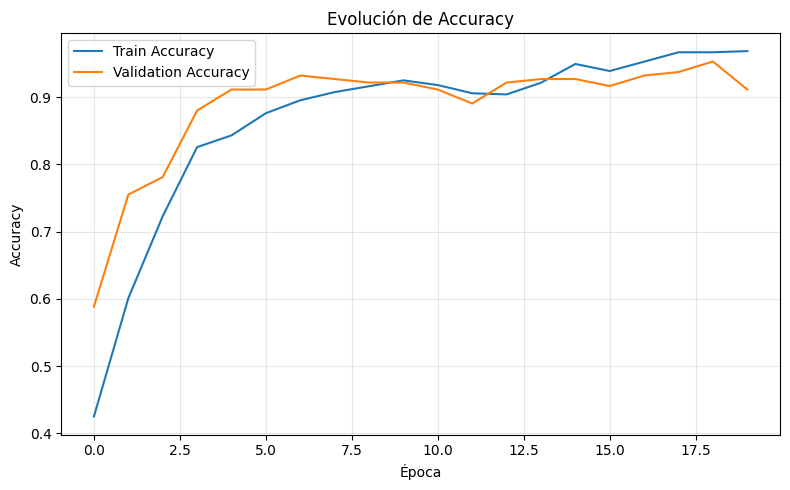

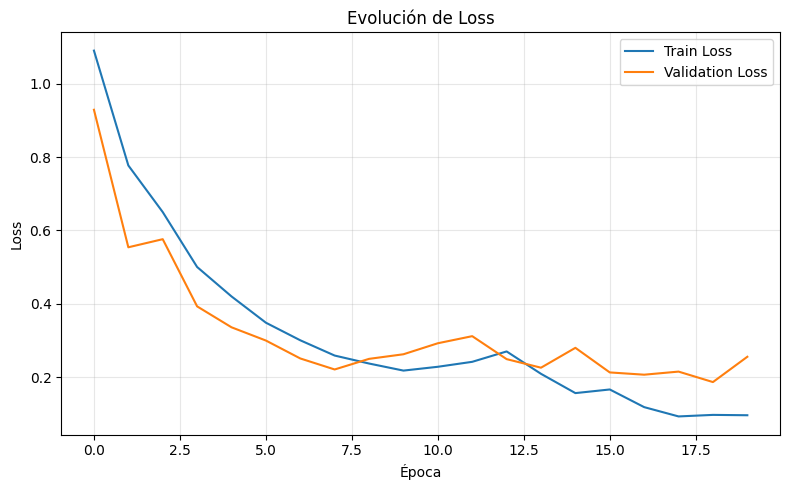

In [34]:
# =========================================================
# 7. CURVAS DE ENTRENAMIENTO
# =========================================================
# Estas curvas permiten analizar si el modelo mejora de
# forma estable y si aparece sobreajuste.

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Evolución de Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolución de Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


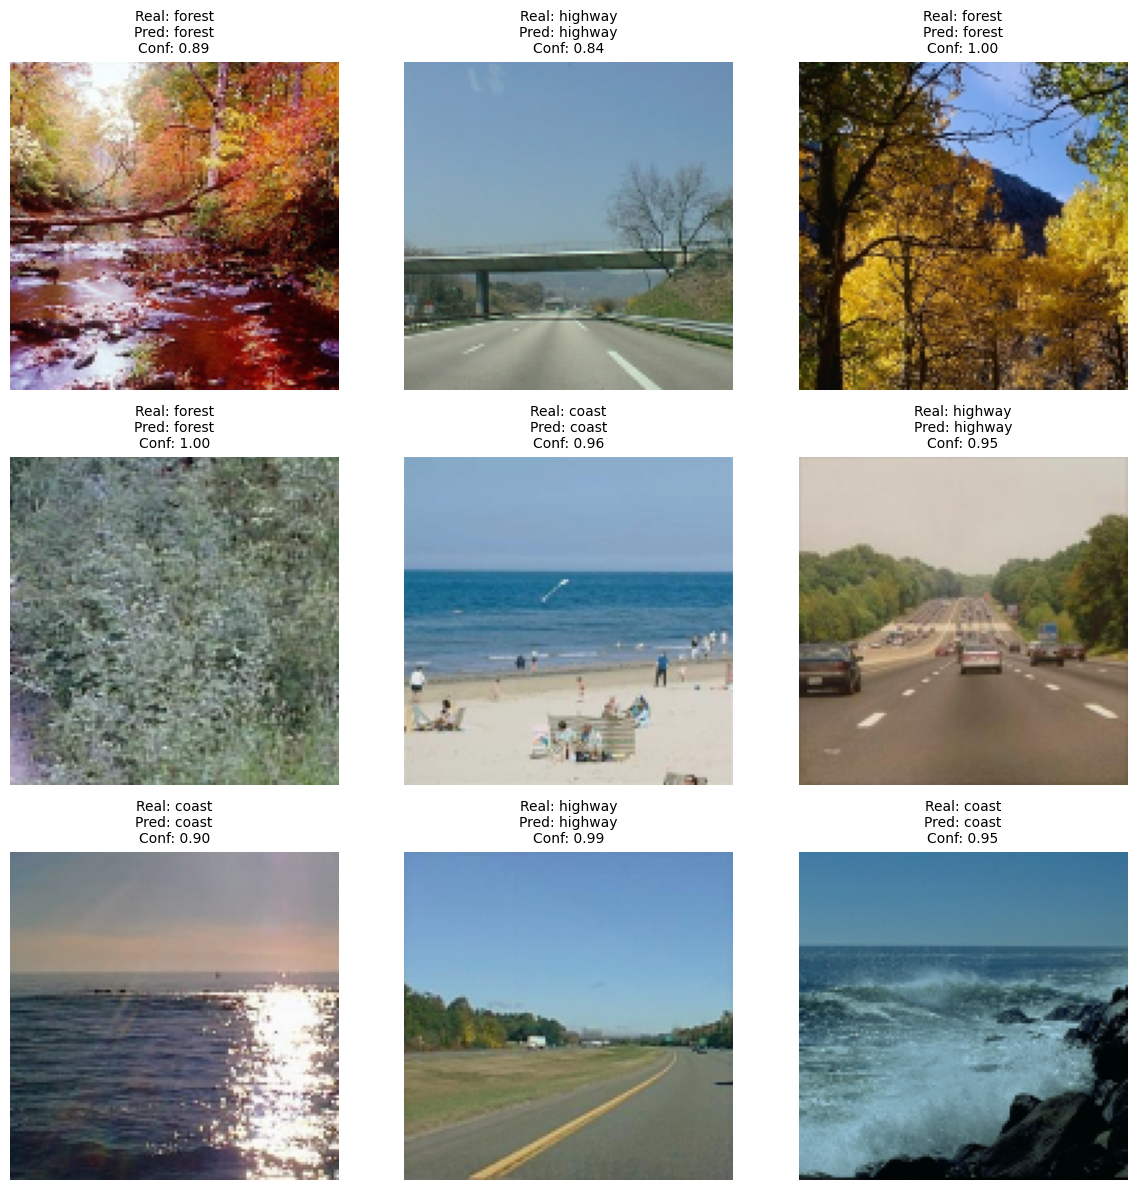

In [36]:
# =========================================================
# 8. VISUALIZACIÓN DE ALGUNAS PREDICCIONES
# =========================================================
# Se muestran ejemplos del conjunto test con:
#   - clase real
#   - clase predicha
#   - confianza máxima del modelo

num_samples = min(9, len(testX))
indices = np.random.choice(len(testX), size=num_samples, replace=False)

plt.figure(figsize=(12, 12))

for i, idx in enumerate(indices, 1):
    img = testX[idx]
    true_label = lb.classes_[true_classes[idx]]
    pred_label = lb.classes_[pred_classes[idx]]
    pred_conf = np.max(pred_probs[idx])

    # Convertimos de BGR a RGB solo para visualizar
    img_rgb = img[:, :, ::-1]

    plt.subplot(3, 3, i)
    plt.imshow(img_rgb)
    plt.title(
        f"Real: {true_label}\nPred: {pred_label}\nConf: {pred_conf:.2f}",
        fontsize=10
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

# Análisis de los cambios implementados y comparación entre la Fase 1 y la Fase 2

## Cambios implementados en la Fase 2

En la Fase 2 se modificó la arquitectura base de la CNN manteniendo el enfoque secuencial trabajado en clase. Los cambios realizados fueron los siguientes:

- **Aumento del número de filtros** por capa convolucional:
  - Arquitectura base: `8 -> 16 -> 32`
  - Arquitectura modificada: `16 -> 32 -> 64 -> 64`

- **Adición de una cuarta capa convolucional**, con el propósito de aumentar la profundidad de la red y permitir la extracción de características más complejas.

- **Aumento del número de épocas de entrenamiento**, para que el modelo tuviera mayor oportunidad de ajustar sus parámetros con la nueva capacidad arquitectónica.

Es importante resaltar que en esta fase **no se añadieron técnicas adicionales** como Batch Normalization, Dropout o Data Augmentation, con el fin de mantener la modificación alineada con lo solicitado en la guía: mejorar el modelo mediante cambios en filtros, capas e hiperparámetros.

---

## Comparación de resultados entre Fase 1 y Fase 2

### Resultados de la Fase 1: Baseline corregido

- **Accuracy final en TEST:** 0.9271

**Reporte de clasificación:**

- `coast`: precision = 0.91, recall = 0.89, F1-score = 0.90
- `forest`: precision = 1.00, recall = 0.98, F1-score = 0.99
- `highway`: precision = 0.86, recall = 0.91, F1-score = 0.88

**Promedios:**

- Macro avg: precision = 0.92, recall = 0.93, F1-score = 0.93
- Weighted avg: precision = 0.93, recall = 0.93, F1-score = 0.93

---

### Resultados de la Fase 2: CNN modificada

- **Accuracy final en TEST:** 0.9271
- **Precision macro:** 0.9250
- **Recall macro:** 0.9266
- **F1-score macro:** 0.9257

**Reporte de clasificación:**

- `coast`: precision = 0.92, recall = 0.90, F1-score = 0.91
- `forest`: precision = 0.98, recall = 0.97, F1-score = 0.98
- `highway`: precision = 0.88, recall = 0.91, F1-score = 0.89

---

## Tabla comparativa de métricas

| Métrica / Clase | Fase 1: Baseline corregido | Fase 2: CNN modificada |
|---|---:|---:|
| Accuracy | 0.9271 | 0.9271 |
| Precision macro | 0.92 | 0.9250 |
| Recall macro | 0.93 | 0.9266 |
| F1-score macro | 0.93 | 0.9257 |
| Precision coast | 0.91 | 0.92 |
| Recall coast | 0.89 | 0.90 |
| F1-score coast | 0.90 | 0.91 |
| Precision forest | 1.00 | 0.98 |
| Recall forest | 0.98 | 0.97 |
| F1-score forest | 0.99 | 0.98 |
| Precision highway | 0.86 | 0.88 |
| Recall highway | 0.91 | 0.91 |
| F1-score highway | 0.88 | 0.89 |

---

## Interpretación de la comparación

La comparación entre ambas fases muestra que **la accuracy global no cambió**, ya que en ambos casos fue de **0.9271**. Esto significa que, en términos de porcentaje total de aciertos, la arquitectura modificada no superó al baseline corregido.

Sin embargo, al revisar las métricas por clase, sí se observan algunos cambios relevantes:

- En la clase **`coast`** hubo una **ligera mejora**, pasando de:
  - precision: 0.91 a 0.92
  - recall: 0.89 a 0.90
  - F1-score: 0.90 a 0.91

- En la clase **`highway`**, que era una de las más difíciles, también se presenta una **mejora leve**:
  - precision: 0.86 a 0.88
  - recall: 0.91 se mantiene
  - F1-score: 0.88 a 0.89

- En la clase **`forest`** se observa una **ligera disminución**:
  - precision: 1.00 a 0.98
  - recall: 0.98 a 0.97
  - F1-score: 0.99 a 0.98

En otras palabras, la CNN modificada **redistribuyó el desempeño del modelo**: mejoró un poco en las clases `coast` y `highway`, pero perdió ligeramente en `forest`. Como resultado, el rendimiento global permaneció prácticamente igual.

---

## Análisis de los cambios implementados

El aumento en el número de filtros y la incorporación de una cuarta capa convolucional incrementaron la capacidad de la red para aprender patrones visuales más complejos. No obstante, en este experimento esa mayor capacidad **no se tradujo en una mejora global de la accuracy**.

Esto sugiere que el modelo baseline corregido ya tenía un nivel de desempeño bastante alto para este problema, por lo que una arquitectura más profunda no necesariamente iba a producir una ganancia importante. Aun así, la modificación sí mostró un efecto positivo en clases con mayor dificultad, especialmente `highway`, lo cual indica que una mayor profundidad puede ayudar a mejorar la discriminación en categorías visualmente más ambiguas.

También es importante considerar que la arquitectura modificada incrementó el número de parámetros del modelo, lo que implica una mayor complejidad computacional. En este caso, ese aumento de complejidad produjo solo una mejora marginal en algunas clases, pero no en el rendimiento total.

---

## Conclusiones

1. **La modificación de la arquitectura no mejoró la accuracy global del modelo.**  
   Tanto la Fase 1 como la Fase 2 alcanzaron una accuracy de 0.9271 en el conjunto de prueba, por lo que no se evidencia una mejora general en el número total de aciertos.

2. **La arquitectura modificada sí produjo pequeñas mejoras en clases más complejas.**  
   Las métricas de `coast` y `highway` mejoraron levemente, lo que indica que el aumento de filtros y capas puede aportar a la discriminación de clases más difíciles, aunque ese efecto no fue suficiente para aumentar el rendimiento global.

3. **Un modelo más complejo no garantiza mejores resultados globales.**  
   En este caso, el incremento en filtros y profundidad aumentó la capacidad del modelo, pero también su complejidad, sin lograr una mejora total frente al baseline corregido. Esto demuestra que la relación entre complejidad y desempeño no siempre es directa.

In [37]:
## FASE 3 - CNN CON ARQUITECTURA RESNET
# =========================================================
#
# OBJETIVO:
# Implementar una arquitectura no secuencial usando
# conexiones residuales (ResNet) para comparar contra
# la CNN secuencial de las fases anteriores.
# =========================================================

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Activation,
    Add,
    MaxPooling2D,
    Flatten,
    Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [38]:
# =========================================================
# BLOQUE RESIDUAL
# =========================================================
# Este bloque implementa:
#   salida = F(x) + x
# donde F(x) son convoluciones

def residual_block(x, filters):
    shortcut = x  # conexión directa

    # Primera convolución
    x = Conv2D(filters, (3, 3), padding="same")(x)
    x = Activation("relu")(x)

    # Segunda convolución
    x = Conv2D(filters, (3, 3), padding="same")(x)

    # Ajuste del shortcut si cambia número de filtros
    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), padding="same")(shortcut)

    # Suma residual
    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x

In [39]:
# =========================================================
# CONSTRUCCIÓN DEL MODELO
# =========================================================

inputs = Input(shape=(128, 128, 3))

# Bloque inicial
x = Conv2D(16, (3, 3), padding="same")(inputs)
x = Activation("relu")(x)
x = MaxPooling2D((2, 2))(x)

# Bloque residual 1
x = residual_block(x, 16)
x = MaxPooling2D((2, 2))(x)

# Bloque residual 2
x = residual_block(x, 32)
x = MaxPooling2D((2, 2))(x)

# Clasificador
x = Flatten()(x)
outputs = Dense(3, activation="softmax")(x)

model_resnet = Model(inputs, outputs)

print("====================================================")
print("RESUMEN DEL MODELO RESNET")
print("====================================================")
model_resnet.summary()

RESUMEN DEL MODELO RESNET


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 128, 128,  │          0 │ conv2d_11[0][0]   │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 64, 64,    │          0 │ activation_15[0]… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 64,    │      2,320 │ max_pooling2d_11… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 64, 64,    │          0 │ conv2d_12[0][0]   │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 64,    │      2,320 │ activation_16[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ conv2d_13[0][0],  │
│                     │ 16)               │            │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 32, 32,    │          0 │ activation_17[0]… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 32, 32,    │      4,640 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 32, 32,    │          0 │ conv2d_14[0][0]   │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │        544 │ max_pooling2d_12… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ conv2d_15[0][0],  │
│                     │ 32)               │            │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 32, 32,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 16, 16,    │          0 │ activation_19[0]

 Total params: 44,099 (172.26 KB)

 Trainable params: 44,099 (172.26 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# =========================================================
# COMPILACIÓN
# =========================================================

model_resnet.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)


In [41]:
# =========================================================
# ENTRENAMIENTO
# =========================================================

history_resnet = model_resnet.fit(
    trainX, trainY,
    validation_data=(valX, valY),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 682ms/step - accuracy: 0.4268 - loss: 1.0439 - val_accuracy: 0.7135 - val_loss: 0.7438
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 749ms/step - accuracy: 0.7352 - loss: 0.6444 - val_accuracy: 0.7396 - val_loss: 0.5328
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 701ms/step - accuracy: 0.8153 - loss: 0.4790 - val_accuracy: 0.8646 - val_loss: 0.3865
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 567ms/step - accuracy: 0.8676 - loss: 0.3638 - val_accuracy: 0.8854 - val_loss: 0.3253
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 675ms/step - accuracy: 0.8780 - loss: 0.3153 - val_accuracy: 0.9062 - val_loss: 0.2898
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 679ms/step - accuracy: 0.9111 - loss: 0.2451 - val_accuracy: 0.9167 - val_loss: 0.2548
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 549ms/step - accuracy: 0.9251 - loss: 0.2116 - val_accuracy: 0.9062 - val_loss: 0.2799
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 672ms/step - accuracy: 0.9547 - loss: 0.1850 - val_accu

In [42]:
# =========================================================
# EVALUACIÓN
# =========================================================

pred_probs = model_resnet.predict(testX)
pred_classes = pred_probs.argmax(axis=1)
true_classes = testY.argmax(axis=1)

from sklearn.metrics import classification_report, accuracy_score

print("\n====================================================")
print("RESULTADOS RESNET")
print("====================================================")
print("Accuracy:", accuracy_score(true_classes, pred_classes))

print("\nReporte de clasificación:")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=lb.classes_
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step

RESULTADOS RESNET
Accuracy: 0.921875

Reporte de clasificación:
              precision    recall  f1-score   support

       coast       0.91      0.89      0.90        72
      forest       0.97      1.00      0.99        66
     highway       0.87      0.87      0.87        54

    accuracy                           0.92       192
   macro avg       0.92      0.92      0.92       192
weighted avg       0.92      0.92      0.92       192



6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step


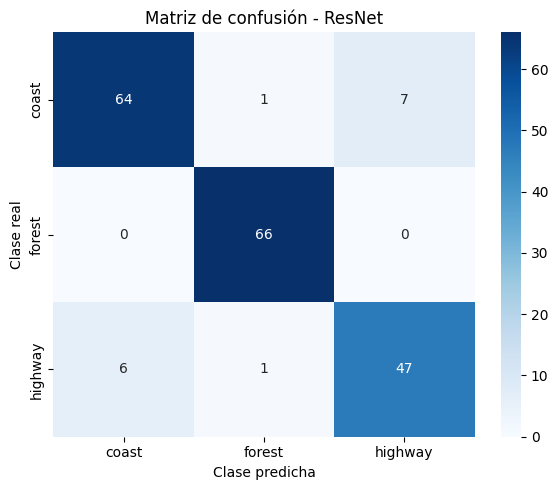

In [43]:
# =========================================================
# MATRIZ DE CONFUSIÓN - RESNET
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predicciones sobre el conjunto de prueba
pred_probs_resnet = model_resnet.predict(testX, batch_size=32)
pred_classes_resnet = pred_probs_resnet.argmax(axis=1)
true_classes = testY.argmax(axis=1)

# Matriz de confusión
cm = confusion_matrix(true_classes, pred_classes_resnet)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lb.classes_,
    yticklabels=lb.classes_
)
plt.title('Matriz de confusión - ResNet')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.tight_layout()
plt.show()

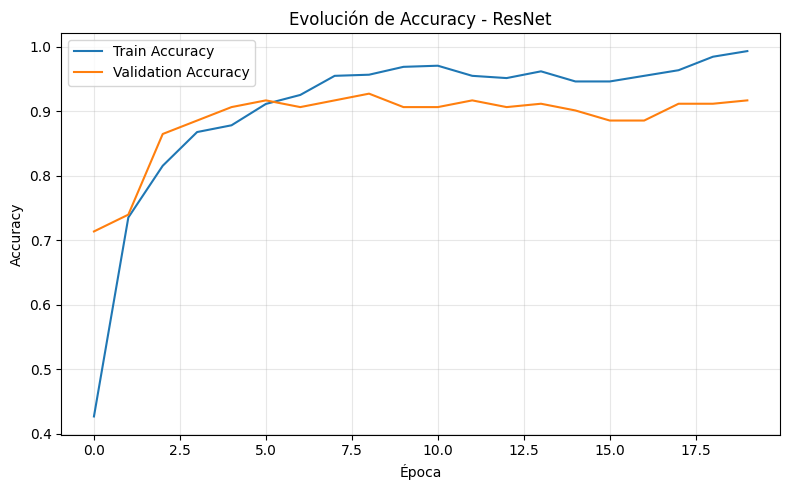

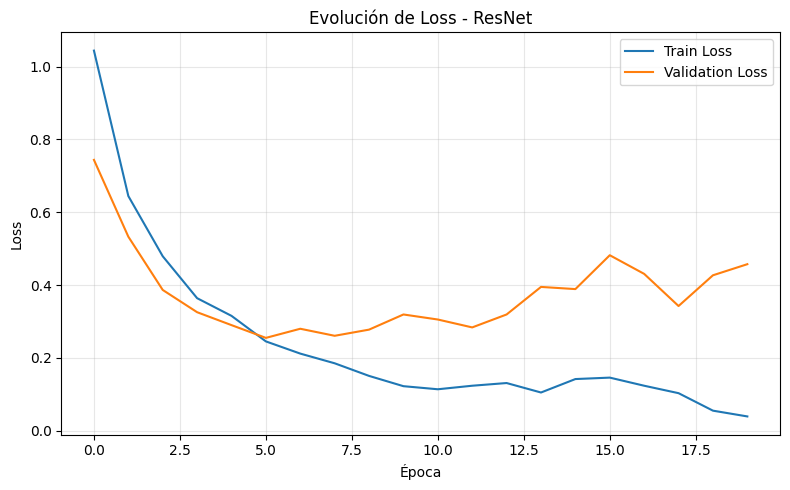

In [44]:
# =========================================================
# CURVAS DE APRENDIZAJE - RESNET
# =========================================================

import matplotlib.pyplot as plt

# -------------------------
# Accuracy
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')

plt.title('Evolución de Accuracy - ResNet')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# Loss
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')

plt.title('Evolución de Loss - ResNet')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis de la Fase 3 (ResNet) y comparación entre las tres fases

## Descripción de la Fase 3

En esta fase se implementó una arquitectura no secuencial basada en **ResNet**, utilizando bloques residuales con conexiones tipo *skip connection*. A diferencia de las fases anteriores, donde la red era estrictamente secuencial, esta arquitectura permite que la información fluya directamente entre capas, facilitando el entrenamiento de modelos más profundos y mejorando la estabilidad del aprendizaje.

---

## Resultados de la Fase 3 (ResNet)

- **Accuracy:** 0.9219  
- **Precision macro:** ~0.92  
- **Recall macro:** ~0.92  
- **F1-score macro:** ~0.92  

### Reporte por clase

- `coast`: F1 = 0.90  
- `forest`: F1 = 0.99  
- `highway`: F1 = 0.87  

---

## Comparación global entre fases

| Métrica | Fase 1 (Baseline) | Fase 2 (CNN modificada) | Fase 3 (ResNet) |
|--------|-------------------|--------------------------|-----------------|
| Accuracy | **0.9271** | **0.9271** | 0.9219 |
| Precision macro | 0.92 | **0.9250** | 0.92 |
| Recall macro | 0.93 | **0.9266** | 0.92 |
| F1-score macro | 0.93 | **0.9257** | 0.92 |

---

## Comparación por clase

### Clase `forest`
- Fase 1: F1 = 0.99  
- Fase 2: F1 = 0.98  
- Fase 3: F1 = 0.99  

→ Se mantiene como la clase más fácil de clasificar en todas las arquitecturas.

---

### Clase `coast`
- Fase 1: F1 = 0.90  
- Fase 2: F1 = 0.91  
- Fase 3: F1 = 0.90  

→ No presenta mejoras significativas con arquitecturas más complejas.

---

### Clase `highway`
- Fase 1: F1 = 0.88  
- Fase 2: F1 = 0.89  
- Fase 3: F1 = 0.87  

→ La CNN modificada (Fase 2) fue la que mejor desempeño logró en esta clase, mientras que ResNet presentó una leve disminución.

---

## Análisis de la matriz de confusión (ResNet)

- Se mantiene la **confusión entre `coast` y `highway`**, lo cual es consistente con fases anteriores.
- La clase `forest` presenta clasificación casi perfecta.
- ResNet no logra reducir significativamente los errores entre clases visualmente similares.

---

## Análisis de las curvas de entrenamiento

- La **accuracy de entrenamiento alcanza valores cercanos a 1.0**, lo que indica alta capacidad de ajuste.
- La **accuracy de validación se estabiliza alrededor de 0.91–0.93**, sin mejoras significativas respecto a fases anteriores.
- Se observa un **sobreajuste más evidente** que en las otras fases:
  - la brecha entre entrenamiento y validación es mayor,
  - la pérdida de validación tiende a aumentar en las últimas épocas.

---

## Interpretación general de los resultados

La implementación de ResNet introdujo una arquitectura más avanzada, con mejor flujo de información gracias a las conexiones residuales. Sin embargo, en este problema específico:

- No se logró mejorar el desempeño global respecto a la CNN secuencial.
- El modelo mostró mayor capacidad (mayor ajuste en entrenamiento), pero sin mejoras en generalización.
- Esto sugiere que el dataset y el problema no requieren una arquitectura tan compleja.

---

## Conclusiones

1. **La arquitectura no secuencial (ResNet) no superó el desempeño de las CNN secuenciales.**  
   A pesar de ser una arquitectura más avanzada, la accuracy final fue menor que en las fases anteriores, lo que indica que mayor complejidad no garantiza mejores resultados.

2. **La CNN modificada (Fase 2) ofreció el mejor balance entre rendimiento y complejidad.**  
   El incremento en filtros y capas permitió mejorar ligeramente el desempeño, especialmente en la clase más difícil (`highway`), sin introducir inestabilidad en el entrenamiento.

3. **El problema de clasificación está bien resuelto con arquitecturas relativamente simples.**  
   El dataset y las características visuales de las clases permiten que modelos secuenciales logren un alto desempeño, por lo que arquitecturas más complejas como ResNet no aportan ventajas significativas en este caso.

4. **Existe un compromiso claro entre complejidad y generalización.**  
   A medida que aumenta la complejidad del modelo, también aumenta el riesgo de sobreajuste, especialmente en datasets de tamaño moderado como el utilizado en este proyecto.

---